# Statistical Classification and Logistic Regression

## CSCN8010 - Machine Learning Fundamentals

---

**Presented by Group 2**

| Name | Role |
| :--- | :--- |
| **Ali Cihan Ozdemir** | Lead Presenter |
| **Lohith Reddy Danda** | Co-Presenter |
| **Roshan Bartaul** | Co-Presenter |

**Instructor:** Professor David

---

## 📊 Agenda

1. Introduction to Statistical Classification
2. From Linear Regression to Logistic Regression
3. The Sigmoid Function
4. Building a Logistic Regression Model
5. Log-Loss (Cross-Entropy) Function
6. Model Evaluation Metrics
7. Live Demo & Code Walkthrough

---

# 1. Introduction to Statistical Classification

## What is Classification?

**Classification** is the process of taking an input and assigning it to a specific category or **class**.

Think of it like sorting:
- 🎯 Is this email Spam or Not Spam?
- 🏥 Will this patient develop a certain disease? Yes/No
- 📝 Will this student Pass or Fail?
- 🖼️ Is this image a Cat or Dog?

## Key Terminology

| Term | Definition |
| :--- | :--- |
| **Classifier** | The algorithm that performs classification (e.g., Logistic Regression) |
| **Features** | Input variables used to make decisions |
| **Classes/Labels** | The categories we predict (e.g., Pass/Fail, Spam/Not Spam) |
| **Decision Boundary** | The line/surface that separates different classes |

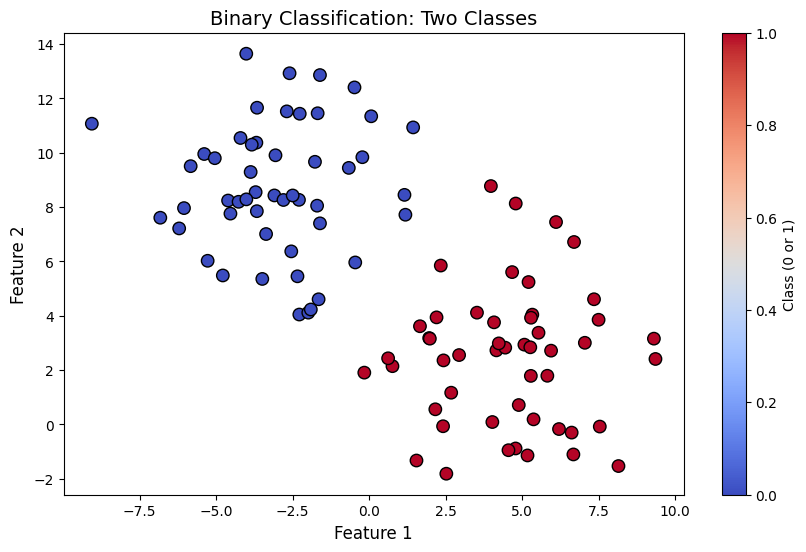

✅ We have 2 classes: Class 0 (Blue) and Class 1 (Red)
✅ The goal is to find a boundary that separates these classes


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Let's visualize a simple classification problem
# We'll create two clusters of data points
X, y = make_blobs(n_samples=100, centers=2, n_features=2, 
                  random_state=42, cluster_std=2.5)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='black', s=80)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Binary Classification: Two Classes', fontsize=14)
plt.colorbar(label='Class (0 or 1)')
plt.show()

print("✅ We have 2 classes: Class 0 (Blue) and Class 1 (Red)")
print("✅ The goal is to find a boundary that separates these classes")

---

# 2. From Linear Regression to Logistic Regression

## The Problem with Linear Regression for Classification

Linear regression predicts **continuous values** - but classification needs **discrete classes (0 or 1)**.

Let's see what happens when we use linear regression for classification:

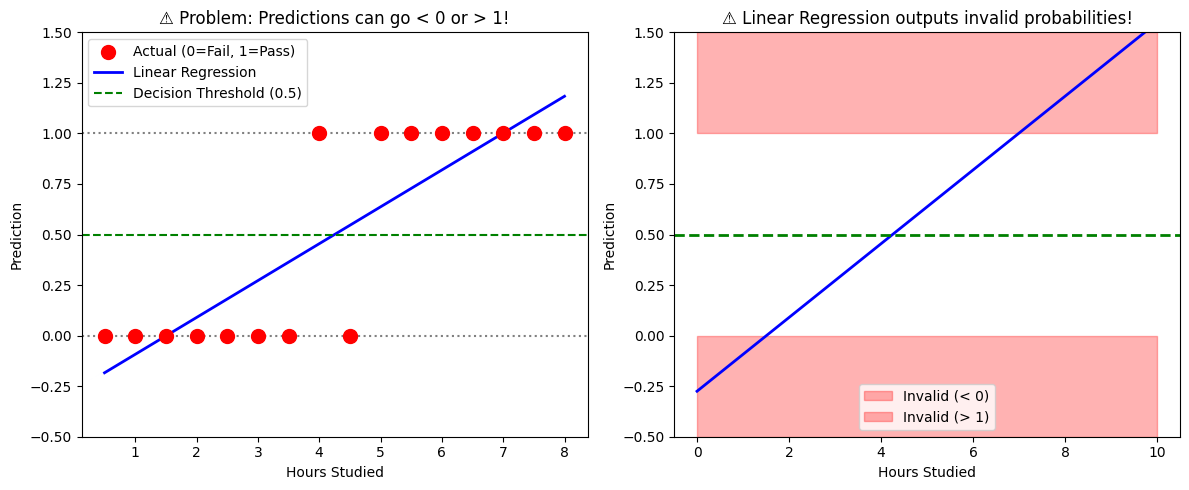


🚫 PROBLEM: Linear regression can predict values like -0.5 or 1.5
🚫 These are NOT valid probabilities!

✅ SOLUTION: Logistic Regression!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Example: Hours studied vs Pass/Fail
hours = np.array([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8]).reshape(-1, 1)
pass_fail = np.array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1])

# Fit linear regression
lr = LinearRegression()
lr.fit(hours, pass_fail)
predictions = lr.predict(hours)

plt.figure(figsize=(12, 5))

# Plot 1: Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(hours, pass_fail, color='red', s=100, zorder=5, label='Actual (0=Fail, 1=Pass)')
plt.plot(hours, predictions, color='blue', linewidth=2, label='Linear Regression')
plt.axhline(y=0.5, color='green', linestyle='--', label='Decision Threshold (0.5)')
plt.axhline(y=0, color='gray', linestyle=':')
plt.axhline(y=1, color='gray', linestyle=':')
plt.xlabel('Hours Studied')
plt.ylabel('Prediction')
plt.title('⚠️ Problem: Predictions can go < 0 or > 1!')
plt.legend()
plt.ylim(-0.5, 1.5)

# Plot 2: Show the problem
plt.subplot(1, 2, 2)
test_hours = np.linspace(0, 10, 100).reshape(-1, 1)
test_pred = lr.predict(test_hours)
plt.plot(test_hours, test_pred, color='blue', linewidth=2)
plt.axhline(y=0.5, color='green', linestyle='--', linewidth=2)
plt.fill_between(test_hours.flatten(), 0, -0.5, alpha=0.3, color='red', label='Invalid (< 0)')
plt.fill_between(test_hours.flatten(), 1, 1.5, alpha=0.3, color='red', label='Invalid (> 1)')
plt.xlabel('Hours Studied')
plt.ylabel('Prediction')
plt.title('⚠️ Linear Regression outputs invalid probabilities!')
plt.ylim(-0.5, 1.5)
plt.legend()

plt.tight_layout()
plt.show()

print("\n🚫 PROBLEM: Linear regression can predict values like -0.5 or 1.5")
print("🚫 These are NOT valid probabilities!")
print("\n✅ SOLUTION: Logistic Regression!" )

---

# 3. The Sigmoid Function (Logistic Function)

## The Solution: Map any value to 0-1 range

The **sigmoid function** (also called logistic function) transforms any real number into a probability between 0 and 1.

### The Formula:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where:
- $z = w_0 + w_1x$ (linear combination of features)
- $w_0$ = bias (intercept)
- $w_1$ = weight (coefficient)
- $x$ = input feature

### Key Properties:
- ✅ Always outputs values between 0 and 1
- ✅ S-curve shape (Sigmoid)
- ✅ At $z=0$, output = 0.5
- ✅ As $z \to \infty$, output $\to 1$
- ✅ As $z \to -\infty$, output $\to 0$

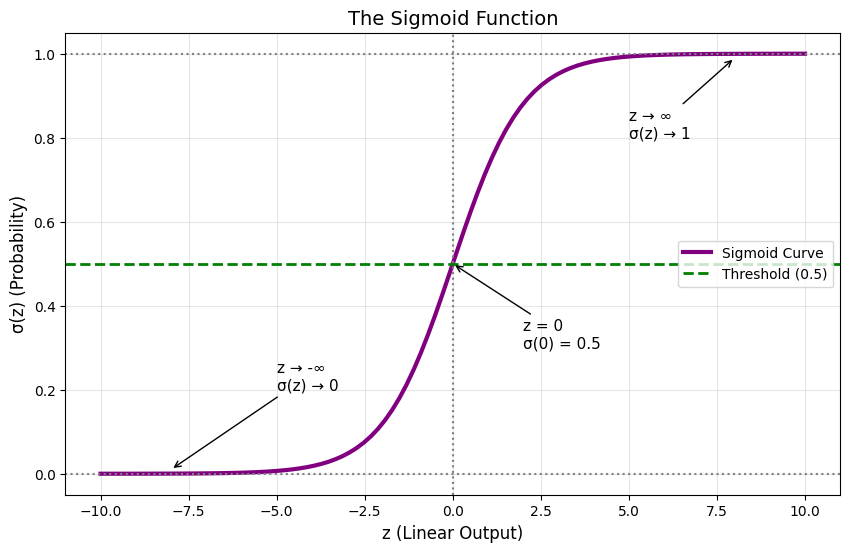

✅ Sigmoid always outputs a value between 0 and 1!
✅ This makes it perfect for probability estimation!


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """The sigmoid function"""
    return 1 / (1 + np.exp(-z))

# Create a range of z values
z = np.linspace(-10, 10, 100)
sigmoid_z = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid_z, color='purple', linewidth=3, label='Sigmoid Curve')
plt.axhline(y=0.5, color='green', linestyle='--', linewidth=2, label='Threshold (0.5)')
plt.axhline(y=0, color='gray', linestyle=':')
plt.axhline(y=1, color='gray', linestyle=':')
plt.axvline(x=0, color='gray', linestyle=':')

# Annotations
plt.annotate('z = 0\nσ(0) = 0.5', xy=(0, 0.5), xytext=(2, 0.3),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='black'))
plt.annotate('z → ∞\nσ(z) → 1', xy=(8, 0.99), xytext=(5, 0.8),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='black'))
plt.annotate('z → -∞\nσ(z) → 0', xy=(-8, 0.01), xytext=(-5, 0.2),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='black'))

plt.xlabel('z (Linear Output)', fontsize=12)
plt.ylabel('σ(z) (Probability)', fontsize=12)
plt.title('The Sigmoid Function', fontsize=14)
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Sigmoid always outputs a value between 0 and 1!")
print("✅ This makes it perfect for probability estimation!")

## How Classification Works with Sigmoid

Once we have a probability from sigmoid, we use a **threshold** to make a final decision:

| Probability | Classification |
| :--- | :--- |
| $\sigma(z) \geq 0.5$ | **Class 1** (e.g., Pass) |
| $\sigma(z) < 0.5$ | **Class 0** (e.g., Fail) |

---

# 4. Building a Logistic Regression Model

Let's implement logistic regression using Python and scikit-learn:

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Dataset: Hours studied vs Pass/Fail
hours = np.array([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8]).reshape(-1, 1)
pass_fail = np.array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1])

# Create and train the model
model = LogisticRegression()
model.fit(hours, pass_fail)

# Make predictions
probabilities = model.predict_proba(hours)[:, 1]  # Probability of passing
predictions = model.predict(hours)  # Final classification

print("=" * 60)
print("LOGISTIC REGRESSION MODEL RESULTS")
print("=" * 60)
print(f"\n📊 Model Coefficient (weight): {model.coef_[0][0]:.4f}")
print(f"📊 Model Intercept (bias): {model.intercept_[0]:.4f}")
print("\n" + "-" * 60)
print("Predictions:")
print("-" * 60)
print(f"{'Hours':<10} {'Actual':<10} {'Probability':<15} {'Predicted':<10}")
print("-" * 60)
for h, a, p, pred in zip(hours.flatten(), pass_fail, probabilities, predictions):
    print(f"{h:<10} {a:<10} {p:<15.4f} {pred:<10}")

LOGISTIC REGRESSION MODEL RESULTS

📊 Model Coefficient (weight): 1.3248
📊 Model Intercept (bias): -5.6305

------------------------------------------------------------
Predictions:
------------------------------------------------------------
Hours      Actual     Probability     Predicted 
------------------------------------------------------------
0.5        0          0.0069          0         
1.0        0          0.0133          0         
1.5        0          0.0255          0         
2.0        0          0.0483          0         
2.5        0          0.0896          0         
3.0        0          0.1603          0         
3.5        0          0.2702          0         
4.0        1          0.4180          0         
4.5        0          0.5821          1         
5.0        1          0.7298          1         
5.5        1          0.8397          1         
6.0        1          0.9104          1         
6.5        1          0.9517          1         
7.0        

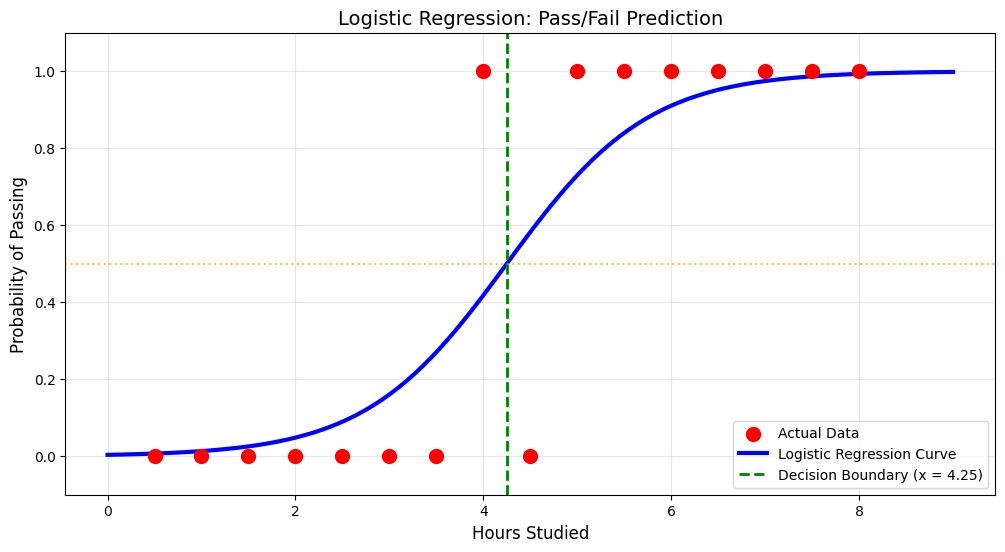


✅ Decision Boundary: At 4.25 hours, the probability of passing is 50%
✅ Students studying more than ~3.5 hours are predicted to PASS


In [5]:
# Visualize the logistic regression results
plt.figure(figsize=(12, 6))

# Scatter plot of actual data
plt.scatter(hours, pass_fail, color='red', s=100, zorder=5, label='Actual Data')

# Plot the sigmoid curve
x_test = np.linspace(0, 9, 100).reshape(-1, 1)
y_prob = model.predict_proba(x_test)[:, 1]
plt.plot(x_test, y_prob, color='blue', linewidth=3, label='Logistic Regression Curve')

# Decision boundary
boundary = -model.intercept_[0] / model.coef_[0][0]
plt.axvline(x=boundary, color='green', linestyle='--', linewidth=2, 
            label=f'Decision Boundary (x = {boundary:.2f})')
plt.axhline(y=0.5, color='orange', linestyle=':', alpha=0.7)

plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Probability of Passing', fontsize=12)
plt.title('Logistic Regression: Pass/Fail Prediction', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.show()

print(f"\n✅ Decision Boundary: At {boundary:.2f} hours, the probability of passing is 50%")
print("✅ Students studying more than ~3.5 hours are predicted to PASS")

---

# 5. Log-Loss Function (Cross-Entropy Loss)

## How do we measure how good our model is?

**Log-Loss** measures how well the predicted probabilities match the actual labels.

### The Formula:

$$
\text{LogLoss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(p_i) + (1 - y_i) \cdot \log(1 - p_i) \right]
$$

Where:
- $y_i$ = actual label (0 or 1)
- $p_i$ = predicted probability

### Key Insight:
- **Low Log-Loss** = Model is confident AND correct ✅
- **High Log-Loss** = Model is confident BUT wrong ❌
- Log-Loss heavily penalizes confident wrong predictions!

In [6]:
def log_loss(y_true, y_prob):
    """Calculate log-loss (cross-entropy)"""
    eps = 1e-15  # Avoid log(0)
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

# Calculate log-loss for our model
ll = log_loss(pass_fail, probabilities)
print("=" * 60)
print("LOG-LOSS CALCULATION")
print("=" * 60)
print(f"\n📊 Log-Loss: {ll:.4f}")
print("\n📝 Interpretation:")
print(f"   - A log-loss of {ll:.4f} indicates the model's predictions")
print("     are reasonably good (closer to 0 is better)")
print("\n💡 Remember: Lower Log-Loss = Better Model!")

LOG-LOSS CALCULATION

📊 Log-Loss: 0.1940

📝 Interpretation:
   - A log-loss of 0.1940 indicates the model's predictions
     are reasonably good (closer to 0 is better)

💡 Remember: Lower Log-Loss = Better Model!


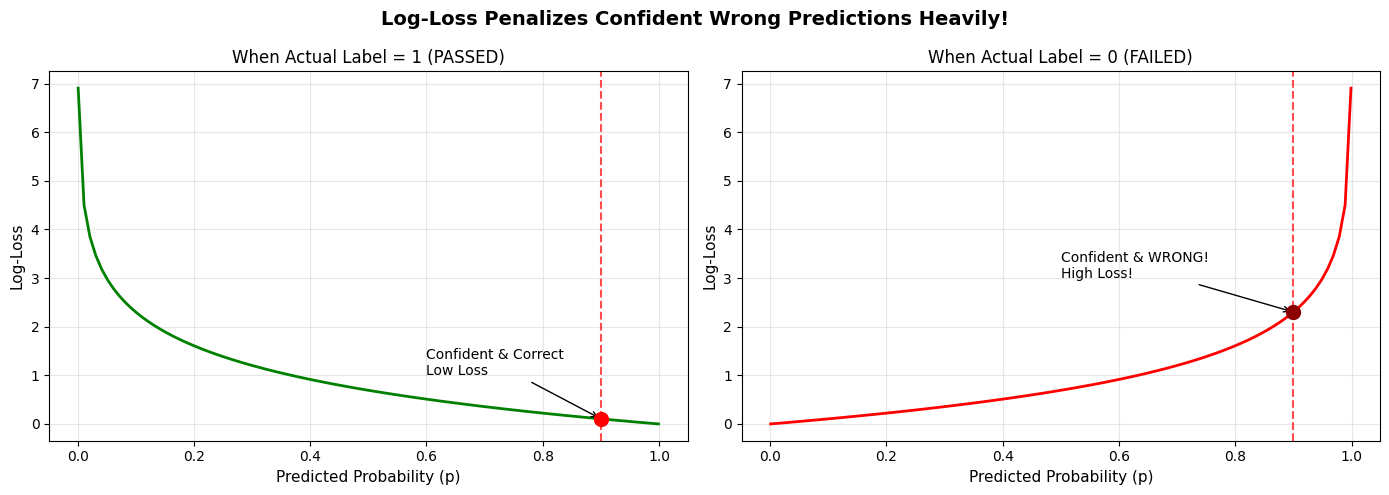


🔑 KEY INSIGHT:
   - Predicting p=0.9 when true label is 1: Loss ≈ 0.105 (Good!)
   - Predicting p=0.9 when true label is 0: Loss ≈ 2.303 (Bad!)
   - Log-loss REALLY punishes confident wrong predictions!


In [7]:
# Visualize how log-loss penalizes wrong predictions
p = np.linspace(0.001, 0.999, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# When actual label is 1
loss_y1 = -np.log(p)
axes[0].plot(p, loss_y1, color='green', linewidth=2)
axes[0].axvline(x=0.9, color='red', linestyle='--', alpha=0.7)
axes[0].scatter([0.9], [-np.log(0.9)], color='red', s=100, zorder=5)
axes[0].annotate('Confident & Correct\nLow Loss', xy=(0.9, -np.log(0.9)), 
                 xytext=(0.6, 1), fontsize=10, arrowprops=dict(arrowstyle='->'))
axes[0].set_xlabel('Predicted Probability (p)', fontsize=11)
axes[0].set_ylabel('Log-Loss', fontsize=11)
axes[0].set_title('When Actual Label = 1 (PASSED)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# When actual label is 0
loss_y0 = -np.log(1 - p)
axes[1].plot(p, loss_y0, color='red', linewidth=2)
axes[1].axvline(x=0.9, color='red', linestyle='--', alpha=0.7)
axes[1].scatter([0.9], [-np.log(1-0.9)], color='darkred', s=100, zorder=5)
axes[1].annotate('Confident & WRONG!\nHigh Loss!', xy=(0.9, -np.log(1-0.9)), 
                 xytext=(0.5, 3), fontsize=10, arrowprops=dict(arrowstyle='->'))
axes[1].set_xlabel('Predicted Probability (p)', fontsize=11)
axes[1].set_ylabel('Log-Loss', fontsize=11)
axes[1].set_title('When Actual Label = 0 (FAILED)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Log-Loss Penalizes Confident Wrong Predictions Heavily!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔑 KEY INSIGHT:")
print("   - Predicting p=0.9 when true label is 1: Loss ≈ 0.105 (Good!)")
print("   - Predicting p=0.9 when true label is 0: Loss ≈ 2.303 (Bad!)")
print("   - Log-loss REALLY punishes confident wrong predictions!")

---

# 6. Model Evaluation Metrics

## Key Metrics for Classification

| Metric | Formula | What it Tells Us |
| :--- | :--- | :--- |
| **Accuracy** | (TP + TN) / Total | Overall correctness |
| **Precision** | TP / (TP + FP) | Of predicted positives, how many are correct? |
| **Recall** | TP / (TP + FN) | Of actual positives, how many did we find? |
| **F1-Score** | 2×(Precision×Recall)/(Precision+Recall) | Balance between precision and recall |

## Confusion Matrix

```
                 Predicted
              |  0   |  1   |
    Actual 0  |  TN  |  FP  |
    Actual 1  |  FN  |  TP  |
```

MODEL EVALUATION METRICS

📊 Accuracy:  0.8750 (87.50%)
📊 Precision: 0.8750
📊 Recall:    0.8750
📊 F1-Score:  0.8750


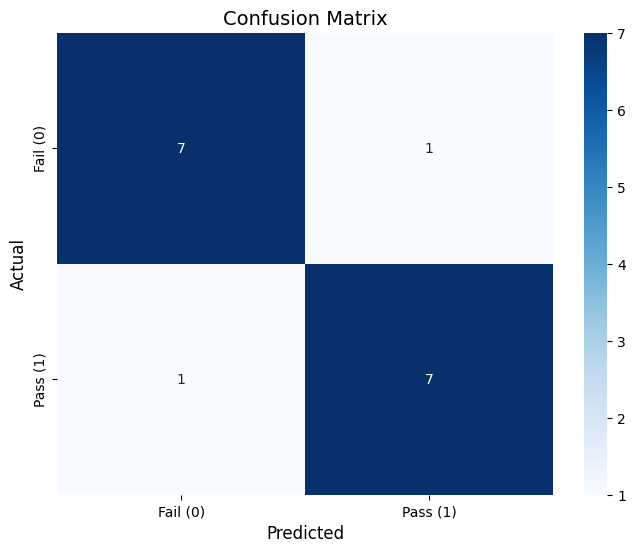


              precision    recall  f1-score   support

        Fail       0.88      0.88      0.88         8
        Pass       0.88      0.88      0.88         8

    accuracy                           0.88        16
   macro avg       0.88      0.88      0.88        16
weighted avg       0.88      0.88      0.88        16



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# Get predictions
y_pred = model.predict(hours)

# Calculate metrics
accuracy = accuracy_score(pass_fail, y_pred)
precision = precision_score(pass_fail, y_pred)
recall = recall_score(pass_fail, y_pred)
f1 = f1_score(pass_fail, y_pred)

print("=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)
print(f"\n📊 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📊 Precision: {precision:.4f}")
print(f"📊 Recall:    {recall:.4f}")
print(f"📊 F1-Score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(pass_fail, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail (0)', 'Pass (1)'],
            yticklabels=['Fail (0)', 'Pass (1)'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

print("\n" + classification_report(pass_fail, y_pred, target_names=['Fail', 'Pass']))

---

# 7. Summary & Key Takeaways

## What We Learned Today

### 1. Why Not Linear Regression?
- Linear regression can output values < 0 or > 1
- These are not valid probabilities!

### 2. The Sigmoid Function
- Maps any real number to (0, 1) range
- Creates an S-curve for probability estimation
- Decision threshold at 0.5

### 3. Logistic Regression
- Uses sigmoid to transform linear output
- Outputs probabilities, not just classes
- Learns optimal weights during training

### 4. Log-Loss
- Measures prediction quality
- Penalizes confident wrong predictions
- Lower is better

### 5. Evaluation Metrics
- Accuracy: Overall correctness
- Precision: Don't over-predict positive
- Recall: Find all positives
- F1-Score: Balance between precision and recall

In [9]:
# Let's try some predictions!
print("=" * 60)
print("LIVE PREDICTION DEMO")
print("=" * 60)

test_hours = [1.5, 3, 4.5, 6, 7.5]

print(f"\n{'Hours Studied':<15} {'Probability of Passing':<25} {'Prediction':<15}")
print("-" * 60)

for h in test_hours:
    prob = model.predict_proba([[h]])[0][1]
    pred = model.predict([[h]])[0]
    result = "PASS" if pred == 1 else "FAIL"
    print(f"{h:<15} {prob:.4f} {'':<15} {result}")

print("\n✅ That's how Logistic Regression works in practice!")

LIVE PREDICTION DEMO

Hours Studied   Probability of Passing    Prediction     
------------------------------------------------------------
1.5             0.0255                 FAIL
3               0.1603                 FAIL
4.5             0.5821                 PASS
6               0.9104                 PASS
7.5             0.9867                 PASS

✅ That's how Logistic Regression works in practice!


---

# ❓ Questions?

## Thank You!

**Created by Group 2**
- Ali Cihan Ozdemir
- Lohith Reddy Danda
- Roshan Bartaul

**Instructor:** Professor David

---

### References:
- Scikit-learn Documentation
- Reference Repository: [GitHub Link]